In [3]:
import zipfile

with zipfile.ZipFile('/content/netflix_titles.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

### 1. Project Introduction

# Netflix Content Analytics

## Project Overview

This project analyzes Netflix's content catalog to identify trends in content type, release patterns, country contributions, ratings, genres, and overall platform growth.

## Objectives

- Understand Netflix's content distribution
- Analyze growth trends over time
- Identify top content-producing countries
- Explore content ratings and genres
- Generate actionable business insights

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib

### 2.Business Understanding


Netflix is one of the world's largest streaming platforms, offering thousands of movies and TV shows across different countries and genres.

Understanding content distribution and growth trends can help stakeholders identify:

* Content production patterns
* Popular content categories
* Geographic distribution of content
* Audience targeting strategies
* Future content investment opportunities

This analysis aims to provide data-driven insights into Netflix's content library and content expansion strategy.


### 3.Import Libraries



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12,6)

### 4. Load Datasets

In [5]:
df = pd.read_csv('../data/netflix_titles.csv')

In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


### 5. Data Set Overview


In [7]:
df.shape

(7787, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [10]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,216,492,7769
top,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,1608,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN


## Initial Observations

- Dataset contains Netflix movies and TV shows.
- Several columns contain missing values.
- Data includes country, director, cast, rating, duration, and release year information.

### 6. Data Quality Assessment

In [11]:
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,False,False,False,False,False,False,False,False,False,False,False,False
7783,False,False,False,False,False,False,False,False,False,False,False,False
7784,False,False,False,True,False,True,False,False,False,False,False,False
7785,False,False,False,True,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


### 6. Data Quality Assessment

In [15]:
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,False,False,False,False,False,False,False,False,False,False,False,False
7783,False,False,False,False,False,False,False,False,False,False,False,False
7784,False,False,False,True,False,True,False,False,False,False,False,False
7785,False,False,False,True,False,False,False,False,False,False,False,False


In [16]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


### 7. Data Cleaning

In [19]:
#Remove duplicates
df = df.drop_duplicates()

In [20]:
#Missing Values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [21]:
#Date Conversion
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

In [22]:
df['date_added'].isnull().sum()

np.int64(98)

In [23]:
#Year conversion
df['year_added'] = df['date_added'].dt.year

In [24]:
df[['date_added', 'year_added']].head()

,date_added,year_added
0,2020-08-14,2020.0
1,2016-12-23,2016.0
2,2018-12-20,2018.0
3,2017-11-16,2017.0
4,2020-01-01,2020.0


In [25]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0


In [26]:
df['country'] = df['country'].str.strip()
df['director'] = df['director'].str.strip()
df['rating'] = df['rating'].str.strip()

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df[df['date_added'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
258,s259,TV Show,A Young Doctor's Notebook and Other Stories,Unknown,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ...",NaN
284,s285,TV Show,Abnormal Summit,"Jung-ah Im, Seung-uk Jo","Hyun-moo Jun, Si-kyung Sung, Se-yoon Yoo",South Korea,NaT,2017,TV-PG,2 Seasons,"International TV Shows, Korean TV Shows, Stand...","Led by a trio of Korean celebs, a multinationa...",NaN
549,s550,TV Show,Anthony Bourdain: Parts Unknown,Unknown,Anthony Bourdain,United States,NaT,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...,NaN
556,s557,TV Show,忍者ハットリくん,Unknown,Unknown,Japan,NaT,2012,TV-Y7,2 Seasons,"Anime Series, Kids' TV","Hailing from the mountains of Iga, Kanzo Hatto...",NaN
690,s691,TV Show,Bad Education,Unknown,"Jack Whitehall, Mathew Horne, Sarah Solemani, ...",United Kingdom,NaT,2014,TV-MA,3 Seasons,"British TV Shows, TV Comedies","A history teacher at the posh Abbey Grove, Alf...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6950,s6951,TV Show,The Tudors,Unknown,"Jonathan Rhys Meyers, Henry Cavill, James Frai...","Ireland, Canada, United States, United Kingdom",NaT,2010,TV-MA,4 Seasons,TV Dramas,All the splendor and scandal of England's 16th...,NaN
6996,s6997,TV Show,The West Wing,Unknown,"Martin Sheen, Rob Lowe, Allison Janney, John S...",United States,NaT,2005,TV-14,7 Seasons,TV Dramas,This powerful political epic chronicles the tr...,NaN
7446,s7447,TV Show,Vroomiz,Unknown,"Joon-seok Song, Jeong-hwa Yang, Sang-hyun Um, ...",South Korea,NaT,2016,TV-Y,3 Seasons,"Kids' TV, Korean TV Shows","For these half-car, half-animal friends, each ...",NaN
7522,s7523,TV Show,Weird Wonders of the World,Unknown,Chris Packham,United Kingdom,NaT,2016,TV-PG,2 Seasons,"British TV Shows, Docuseries, Science & Nature TV",From animal oddities and bizarre science to me...,NaN


In [29]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


In [30]:
df[df['date_added'].isnull()].head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
258,s259,TV Show,A Young Doctor's Notebook and Other Stories,Unknown,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ...",NaN
284,s285,TV Show,Abnormal Summit,"Jung-ah Im, Seung-uk Jo","Hyun-moo Jun, Si-kyung Sung, Se-yoon Yoo",South Korea,NaT,2017,TV-PG,2 Seasons,"International TV Shows, Korean TV Shows, Stand...","Led by a trio of Korean celebs, a multinationa...",NaN
549,s550,TV Show,Anthony Bourdain: Parts Unknown,Unknown,Anthony Bourdain,United States,NaT,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...,NaN
556,s557,TV Show,忍者ハットリくん,Unknown,Unknown,Japan,NaT,2012,TV-Y7,2 Seasons,"Anime Series, Kids' TV","Hailing from the mountains of Iga, Kanzo Hatto...",NaN
690,s691,TV Show,Bad Education,Unknown,"Jack Whitehall, Mathew Horne, Sarah Solemani, ...",United Kingdom,NaT,2014,TV-MA,3 Seasons,"British TV Shows, TV Comedies","A history teacher at the posh Abbey Grove, Alf...",NaN


In [31]:
df['date_added'].isnull().sum()

np.int64(98)

In [32]:
df = df.dropna(subset=['date_added'])

In [33]:
df['year_added'] = df['date_added'].dt.year

In [34]:
df[['date_added', 'year_added']].isnull().sum()

,0
date_added,0
year_added,0


In [35]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# Data Cleaning Summary

The following preprocessing steps were performed:

- Removed duplicate records
- Handled missing values in director, cast, country, and rating columns
- Converted date_added to datetime format
- Extracted year_added from date_added
- Standardized text fields by removing unnecessary whitespace
- Verified data types and dataset consistency

### Handling Missing Values

- Missing values in `director`, `cast`, `country`, and `rating` were replaced with appropriate placeholders.
- 98 records with missing `date_added` values were removed because the date information was essential for time-series analysis.
- A new feature, `year_added`, was extracted from the `date_added` column.

###8. Exploratory Data Analysis & Visualizations

In [36]:
#EDA 1: Movies VS TV shows
df['type'].value_counts()

,count
type,
Movie,5377
TV Show,2312


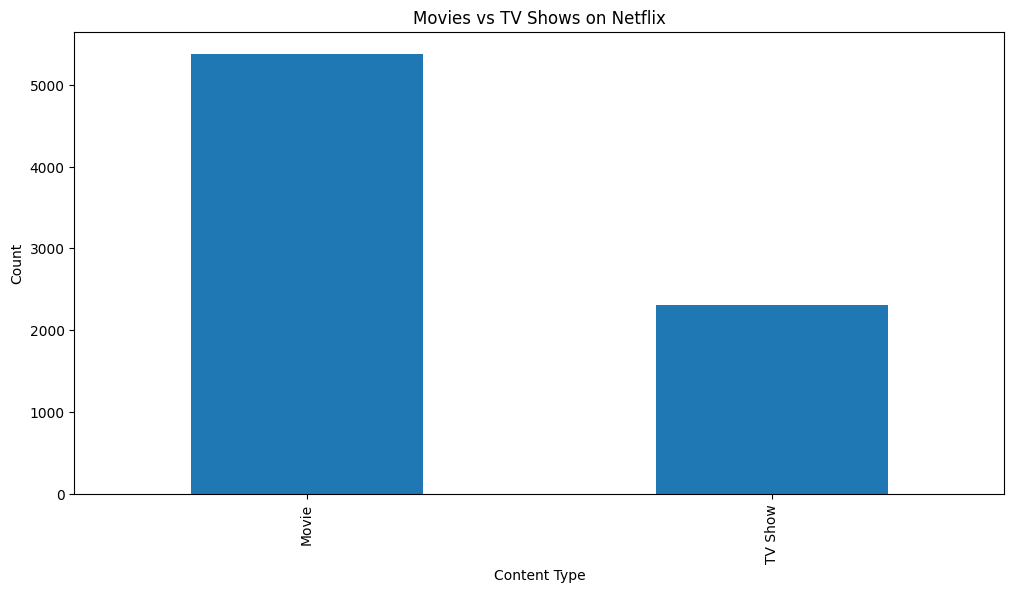

In [37]:
movie_tv = df['type'].value_counts()

movie_tv.plot(
    kind='bar',
    title='Movies vs TV Shows on Netflix'
)

plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

### Insight

Movies significantly outnumber TV Shows on Netflix, indicating a stronger emphasis on movie content within the platform's catalog.

In [38]:
#EDA 2:Movies VS TV shows Percentage
(
    df['type']
    .value_counts(normalize=True)
    * 100
).round(2)


,proportion
type,
Movie,69.93
TV Show,30.07


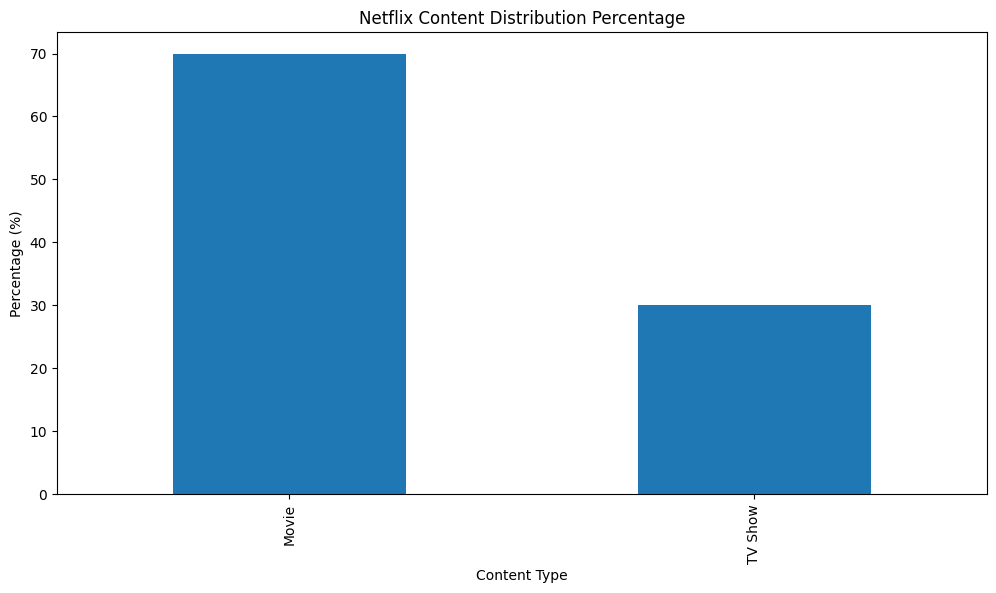

In [58]:
(
    df['type']
    .value_counts(normalize=True)
    * 100
).plot(
    kind='bar'
)

plt.title('Netflix Content Distribution Percentage')
plt.xlabel('Content Type')
plt.ylabel('Percentage (%)')

plt.show()

### Insight

Analyzing percentages provides a clearer understanding of content distribution beyond raw counts.

In [56]:
#EDA 3: Content added over Time
content_growth = (
    df['year_added']
    .value_counts()
    .sort_index()
)

content_growth

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,10
2014,24
2015,79
2016,432


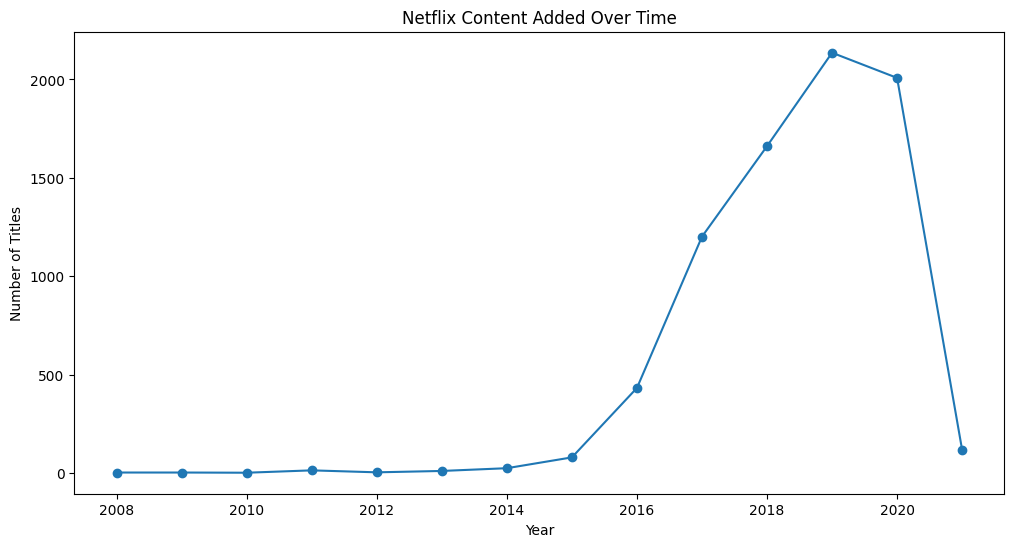

In [57]:
#Plot
content_growth.plot(
    kind='line',
    marker='o'
)

plt.title('Netflix Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

### Insight

Netflix experienced rapid content expansion after 2015, reflecting aggressive growth in its streaming catalog.

In [41]:
#EDA4: Top 10 Countries
country_counts = (
    df['country']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

country_counts


,count
country,
United States,3250
India,989
United Kingdom,704
Unknown,503
Canada,399
France,345
Japan,283
Spain,211
South Korea,207


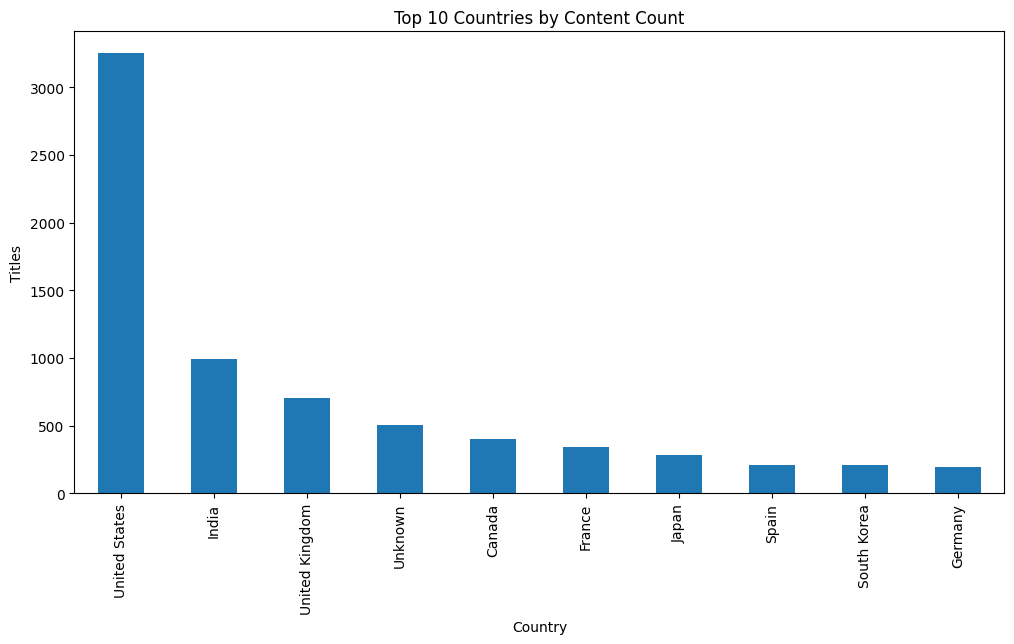

In [42]:
#Plot
country_counts.plot(
    kind='bar'
)

plt.title('Top 10 Countries by Content Count')
plt.xlabel('Country')
plt.ylabel('Titles')

plt.show()

### Insight

The United States contributes the largest number of titles, followed by other major entertainment-producing nations.

In [43]:
#EDA 5:Content Ratings
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,2839
TV-14,1904
TV-PG,781
R,665
PG-13,386
TV-Y,273
TV-Y7,267
PG,247
TV-G,186


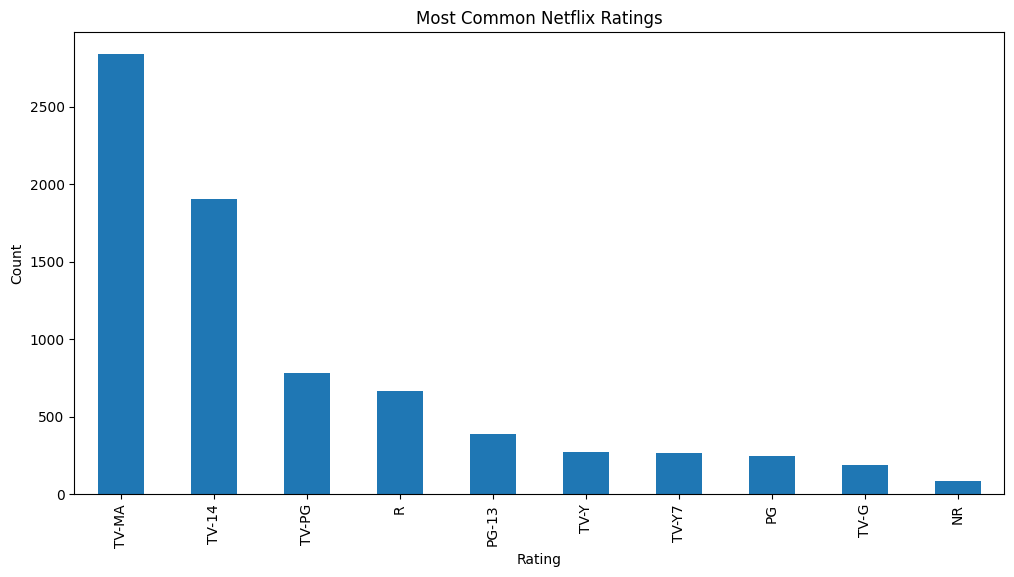

In [44]:
#Plot
df['rating'].value_counts().head(10).plot(
    kind='bar'
)

plt.title('Most Common Netflix Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.show()

### Insight

TV-MA and TV-14 dominate the platform, suggesting a strong focus on content for mature audiences.

In [45]:
#EDA 6:Top Genres
genres = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
)

genres.value_counts().head(10)

,count
listed_in,
International Movies,2437
Dramas,2106
Comedies,1471
International TV Shows,1176
Documentaries,786
Action & Adventure,721
TV Dramas,680
Independent Movies,673
Children & Family Movies,532


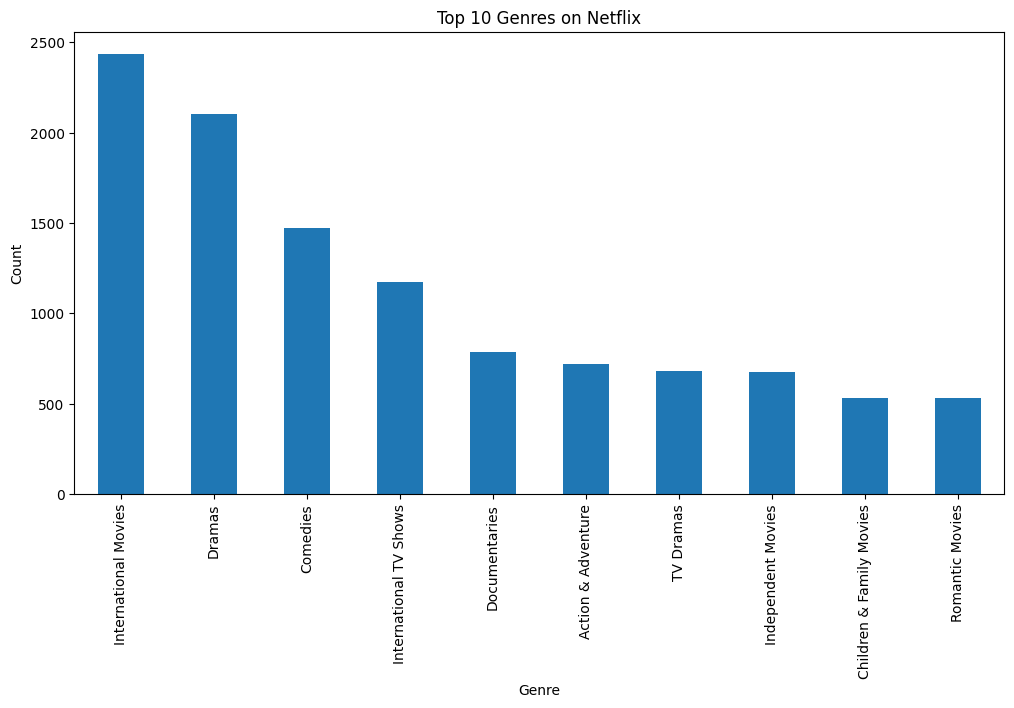

In [46]:
#Plot
genres.value_counts().head(10).plot(
    kind='bar'
)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.show()

### Insight

Drama, International Movies, and Comedy are among the most popular genres available on Netflix.

In [47]:
#EDA 7: Top Directors
top_directors = (
    df[df['director'] != 'Unknown']
    ['director']
    .value_counts()
    .head(10)
)

top_directors

,count
director,
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Youssef Chahine,12
Martin Scorsese,12
Jay Chapman,12
Steven Spielberg,10
David Dhawan,9


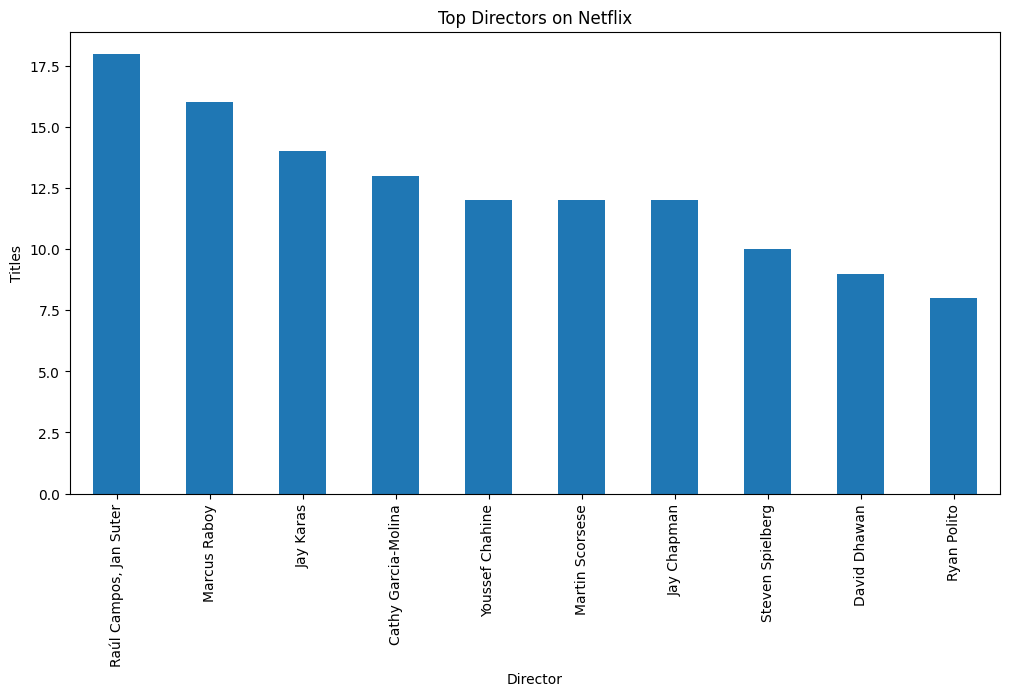

In [48]:
#Plot
top_directors.plot(
    kind='bar'
)

plt.title('Top Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Titles')

plt.show()

In [49]:
#EDA 8:Release Year Distribution
release_years = (
    df['release_year']
    .value_counts()
    .sort_index()
)

release_years.tail()

,count
release_year,
2017,996
2018,1114
2019,996
2020,868
2021,31


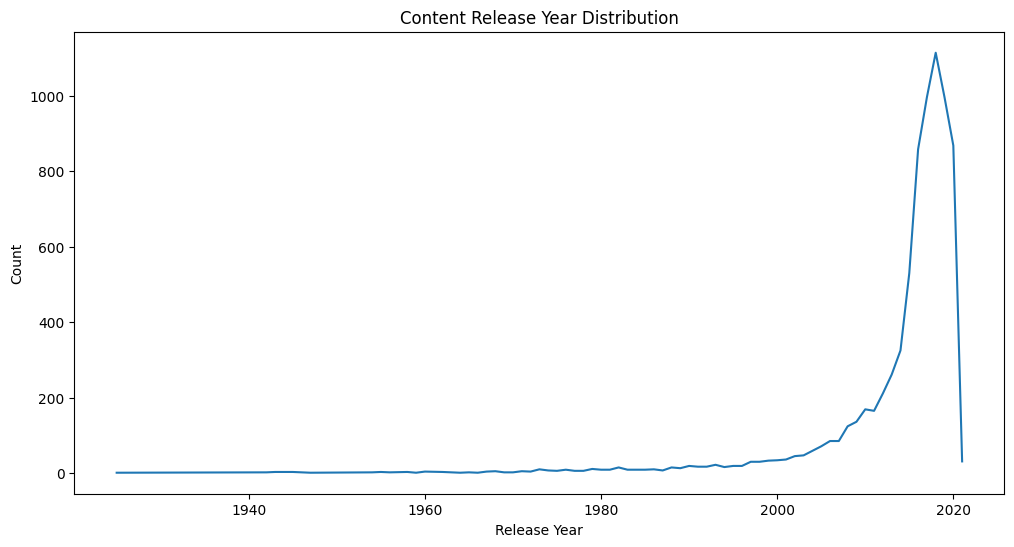

In [50]:
#Plot
release_years.plot(
    kind='line'
)

plt.title('Content Release Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Count')

plt.show()

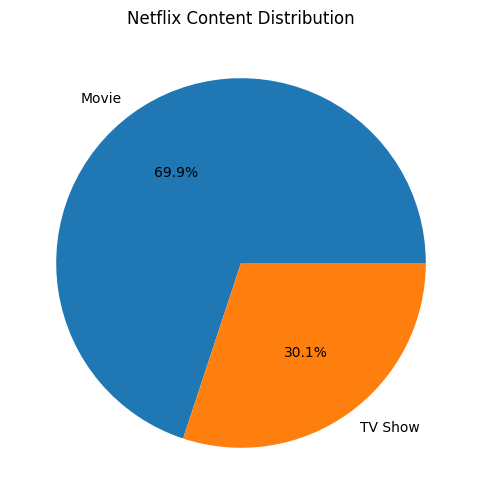

In [51]:
#EDA 9:Movies vs TV shows Pie Charts
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Netflix Content Distribution')

plt.show()

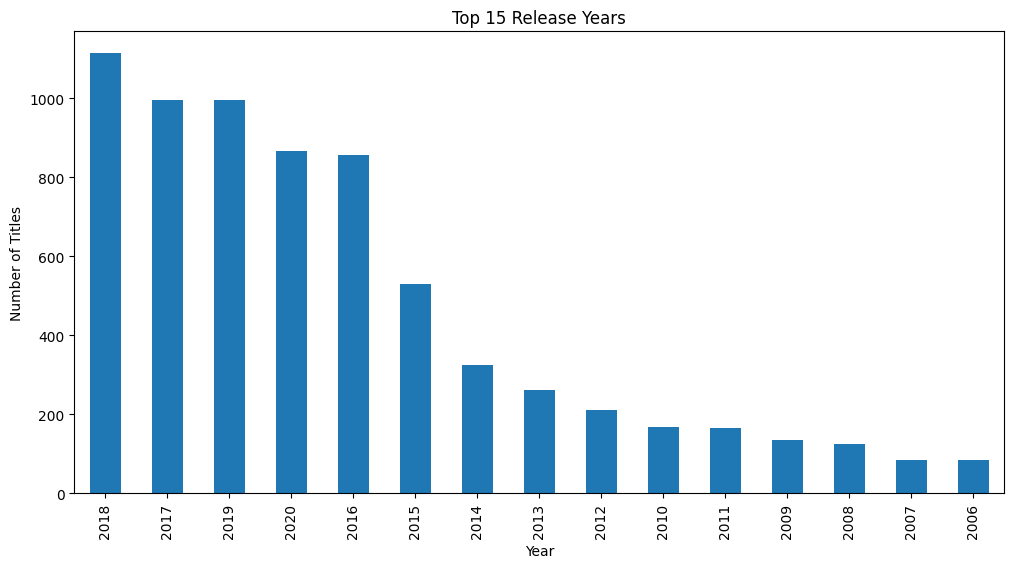

In [52]:
#Top 15 years Release
release_year_counts = (
    df['release_year']
    .value_counts()
    .sort_values(ascending=False)
    .head(15)
)

release_year_counts.plot(kind='bar')

plt.title('Top 15 Release Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

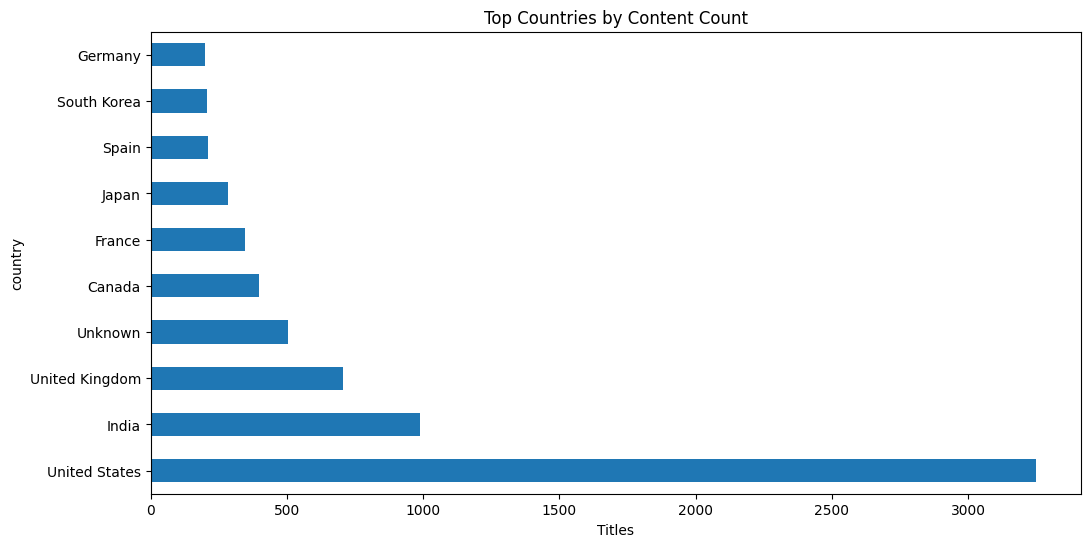

In [53]:
#Top 10 Countries
country_counts.plot(
    kind='barh'
)

plt.title('Top Countries by Content Count')
plt.xlabel('Titles')

plt.show()

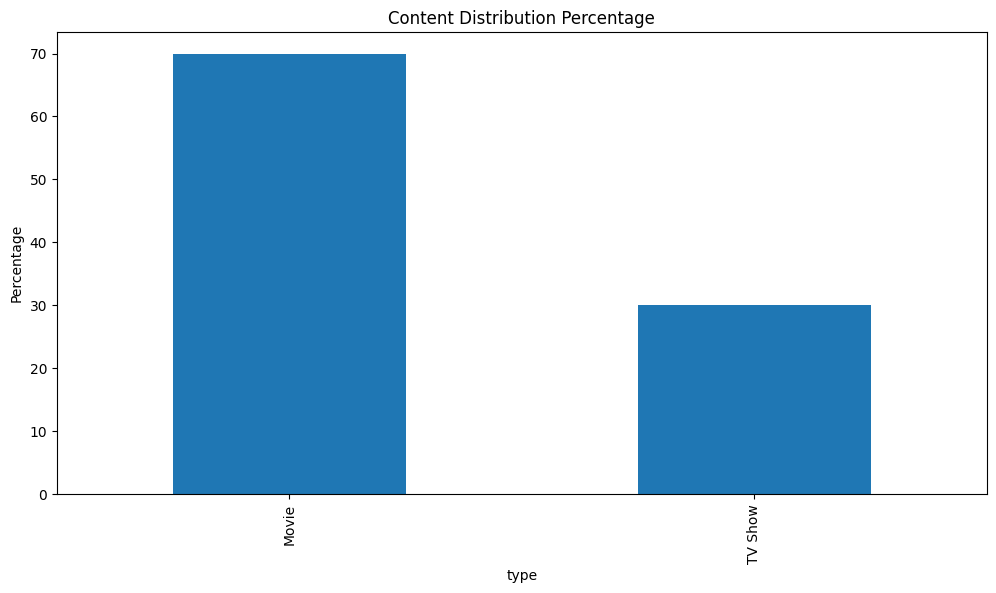

In [54]:
#Movies vs Tv shows percentages
(
    df['type']
    .value_counts(normalize=True)
    * 100
).plot(
    kind='bar'
)

plt.title('Content Distribution Percentage')
plt.ylabel('Percentage')

plt.show()

In [55]:
#EDA 10:Final Insights Section

### Key Findings

1. Movies account for the majority of Netflix content.

2. Netflix experienced substantial growth after 2015.

3. The United States is the largest content contributor.

4. TV-MA and TV-14 ratings dominate the catalog.

5. Drama and International Movies are among the most common genres.

6. Netflix has significantly expanded its global content library over time.

### 9. Insights


### Insight 1: Movies Dominate the Catalog

The analysis shows that Movies account for a significantly larger portion of Netflix's content library than TV Shows.

### Insight 2: Rapid Expansion After 2015

Netflix experienced substantial content growth after 2015, indicating aggressive expansion and increased investment in content acquisition.

### Insight 3: Strong US Content Presence

The United States contributes the largest share of content on the platform, reflecting its dominance in global entertainment production.

### Insight 4: Mature Audience Focus

TV-MA and TV-14 ratings are among the most common, suggesting Netflix primarily targets teen and adult audiences.

### Insight 5: Genre Diversity

Drama, International Movies, and Comedy emerge as the most represented genres, highlighting Netflix's strategy of maintaining broad audience appeal.


### 10. Recommendations

Based on the analysis, the following recommendations can be considered:

1. Continue expanding international content production to strengthen global audience engagement.

2. Invest further in high-performing genres such as Drama and International Movies.

3. Explore opportunities to increase content targeting younger audiences.

4. Maintain a balanced portfolio of Movies and TV Shows to support diverse viewing preferences.

5. Expand content partnerships in emerging entertainment markets to accelerate platform growth.


### 11. Conclusion

This project analyzed Netflix's content catalog to identify trends in content distribution, growth, ratings, genres, and geographic contributions.

The analysis revealed that Movies dominate the platform, content additions increased significantly after 2015, and the United States remains the leading contributor of content.

The findings demonstrate Netflix's rapid expansion strategy and strong emphasis on providing diverse content to a global audience.

Future analysis could incorporate viewer ratings, engagement metrics, and regional performance data to generate deeper business insights.


### 12. Limitations

- The dataset does not include viewer engagement metrics.
- Content popularity and watch-time information are unavailable.
- The analysis focuses only on catalog information.
- Results are limited to the available dataset and may not reflect current Netflix content.